<a href="https://colab.research.google.com/github/swathivenkatesan87/24BAD122-EXP-3/blob/main/Ex_3_24BAD122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              

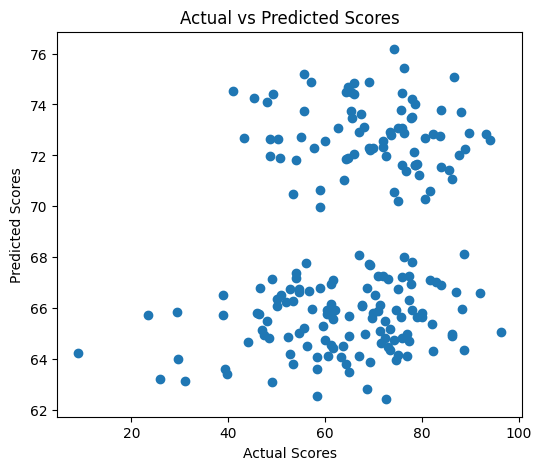

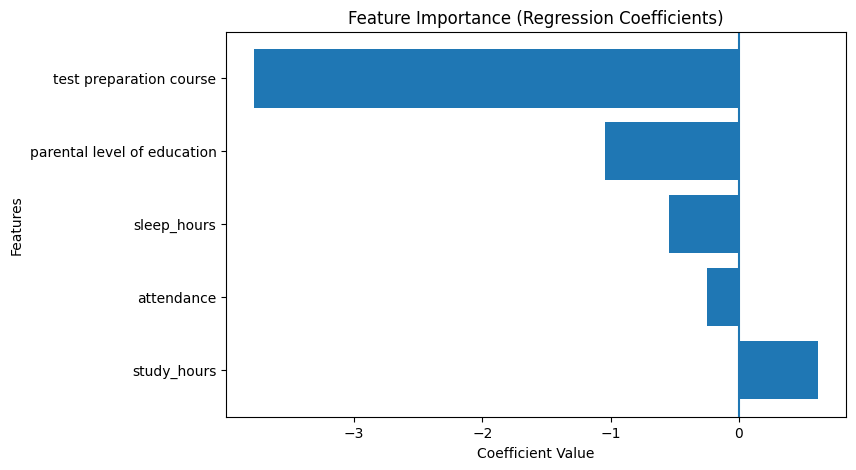

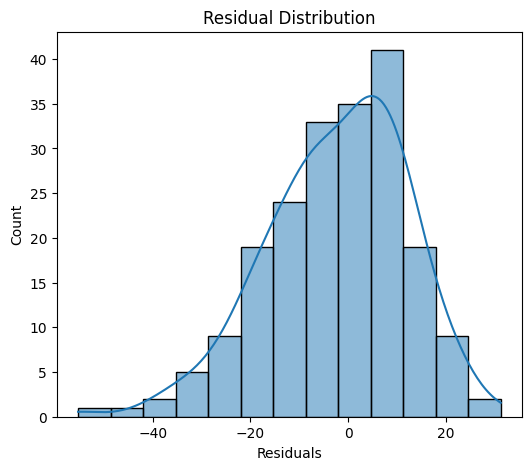

In [ ]:
# -----------------------------------------------------------
# SCENARIO 1 – MULTILINEAR REGRESSION
# Name : SWATHI
# Roll No : 24BAD122
# Problem: Predict Student Academic Performance
# -----------------------------------------------------------

# 1. Import required Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


# 2. Load dataset
# Make sure StudentsPerformance.csv is in the same folder
# ---
data = pd.read_csv("StudentsPerformance.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())


# 3. Data preprocessing and encoding categorical features

le = LabelEncoder()

categorical_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Create additional features (synthetic for lab demonstration)

np.random.seed(10)

data["study_hours"] = np.random.randint(1, 6, size=len(data))
data["attendance"] = np.random.randint(60, 100, size=len(data))
data["sleep_hours"] = np.random.randint(5, 9, size=len(data))

# 4. Compute target variable

data["final_score"] = (
    data["math score"] +
    data["reading score"] +
    data["writing score"]
) / 3
# 5. Handle missing values

data.fillna(data.mean(numeric_only=True), inplace=True)


# 6. Select features and target

X = data[[
    "study_hours",
    "attendance",
    "sleep_hours",
    "parental level of education",
    "test preparation course"
]]

y = data["final_score"]



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 7. Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 8. Train Multilinear Regression model


model = LinearRegression()
model.fit(X_train, y_train)



y_pred = model.predict(X_test)


# 10. Evaluation Metrics

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)


# 11. Regression Coefficients


coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nRegression Coefficients:")
print(coeff_df)


# 12. Optimization – Ridge & Lasso


ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("\nRidge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))


# 1. Predicted vs Actual Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.show()


# 2. Improved Coefficient Comparison (Horizontal Bar Graph)

plt.figure(figsize=(8,5))
plt.barh(coeff_df["Feature"], coeff_df["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance (Regression Coefficients)")
plt.axvline(x=0)
plt.show()


# 3. Residual Distribution Plot

residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()